# 利用非均勻隨機變數模擬股票價格之研究

## 一、研究動機（Introduction）

在 HW1 中，我們利用均勻分布的隨機數來模擬股票價格的隨機漫步。然而，在真實金融市場中，資產報酬通常並非均勻分布，而更常以常態分布或其他非均勻分布來描述。

因此，本研究將延續 HW1 的股票模型，進一步使用非均勻隨機變數來模擬股票價格的變動。透過將均勻分布的隨機數轉換為常態分布，本研究可建立更貼近實際情況的模型。

此外，本研究將比較兩種生成常態分布隨機數的方法：
1. Box-Muller 轉換（由 uniform 轉換）
2. NumPy 套件內建方法

以探討不同方法對模擬結果的影響。

## 二、模型設定（Model Description）

令 $S_t$ 表示第 $t$ 天的股票價格，初始價格為：

$$
S_0 = 100
$$

股票報酬率 $R_t$ 假設服從常態分布：

$$
R_t \sim N(0, \sigma^2)
$$

股票價格依下式更新：

$$
S_{t+1} = S_t (1 + R_t)
$$

其中 $\sigma$ 為波動率，本研究設定 $\sigma = 0.01$。

此模型相較於 HW1 的 ±1 隨機漫步，更能反映金融市場中連續變動的特性。

## 三、非均勻隨機變數生成方法（Non-Uniform RNG）

本研究比較兩種生成常態分布的方法：

### （一）Box-Muller 轉換

Box-Muller 方法可將兩個均勻分布隨機數 $U_1, U_2 \sim Uniform(0,1)$ 轉換為常態分布：

$$
Z = \sqrt{-2 \ln U_1} \cos(2\pi U_2)
$$

此方法為從均勻分布產生非均勻分布的經典方法。

---

### （二）NumPy 內建方法

NumPy 提供直接生成常態分布的函數：

```python
np.random.normal(0,1)

### 可重現性（Reproducibility）

為確保模擬結果可重現，本研究設定固定的隨機種子（seed）。所有隨機數生成皆基於相同的 seed，以確保每次執行結果一致。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

seed = 12345
np.random.seed(seed)

In [2]:
# Box muller

def box_muller(n):
    u1 = np.random.uniform(0,1,n)
    u2 = np.random.uniform(0,1,n)
    
    z = np.sqrt(-2*np.log(u1)) * np.cos(2*np.pi*u2)
    return z

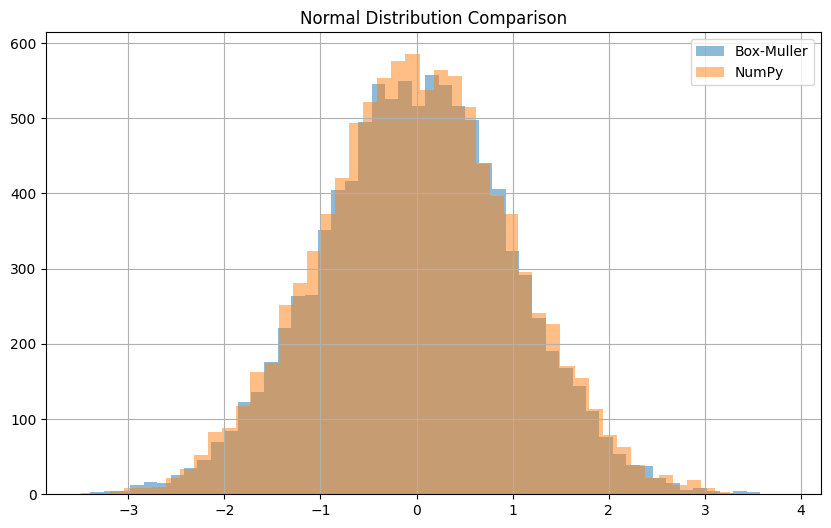

In [3]:
z_bm = box_muller(10000)
z_np = np.random.normal(0,1,10000)

plt.figure(figsize=(10,6))
plt.hist(z_bm, bins=50, alpha=0.5, label="Box-Muller")
plt.hist(z_np, bins=50, alpha=0.5, label="NumPy")
plt.legend()
plt.title("Normal Distribution Comparison")
plt.grid()
plt.show()

## 四、模擬設計（Simulation Design）

- 初始價格：$S_0 = 100$
- 模擬天數：100 天
- 使用常態分布報酬
- 波動率 $\sigma = 0.01$
- 比較兩種方法（Box-Muller 與 NumPy）

In [4]:
def simulate_stock(n_days, s0, returns):
    prices = [s0]
    for r in returns:
        prices.append(prices[-1]*(1+r))
    return prices

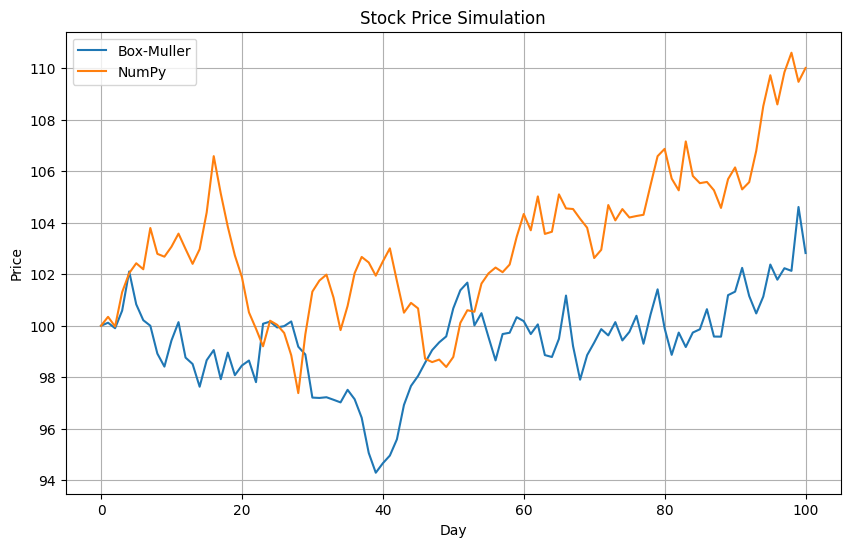

In [5]:
n_days = 100
s0 = 100

returns_bm = box_muller(n_days) * 0.01
returns_np = np.random.normal(0,0.01,n_days)

path_bm = simulate_stock(n_days, s0, returns_bm)
path_np = simulate_stock(n_days, s0, returns_np)

plt.figure(figsize=(10,6))
plt.plot(path_bm, label="Box-Muller")
plt.plot(path_np, label="NumPy")
plt.legend()
plt.title("Stock Price Simulation")
plt.xlabel("Day")
plt.ylabel("Price")
plt.grid()
plt.show()

## 五、模擬結果（Results）

由模擬結果可觀察到，Box-Muller 方法與 NumPy 方法所生成的股票價格路徑呈現不同的變動趨勢。

雖然兩條路徑皆基於相同的分布（常態分布），但由於隨機性，每次生成的報酬序列不同，因此單一路徑之間可能出現明顯差異。

此外，從前述分布比較圖可知，Box-Muller 與 NumPy 所生成的常態分布形狀相似，顯示兩種方法在分布層面上是一致的。

## 六、討論（Discussion）

本研究顯示，即使使用相同的分布（常態分布），不同的隨機樣本仍可能導致顯著不同的股票價格路徑。這是隨機模擬中的正常現象，特別是在樣本數較少（例如單一路徑）時。

因此，僅觀察單一路徑可能無法完整反映模型的統計特性。在實務上，通常需要進行大量模擬，並分析其平均值、變異數或分布，才能得到穩定且可靠的結論。

此外，Box-Muller 方法從均勻分布轉換而來，具有明確的理論基礎；而 NumPy 方法則經過優化，在計算效率上更具優勢。

本研究亦透過固定隨機種子，確保模擬結果具有可重現性，使不同方法之間的比較更加公平。

## 七、未來研究方向（Future Work）

本研究仍可進一步延伸：

1. 進行多次模擬，分析平均路徑與分布特性
2. 比較不同 non-uniform 生成方法（如 inverse transform、rejection sampling）
3. 使用其他分布（如 exponential、lognormal）模擬報酬
4. 建立更真實的金融模型（如幾何布朗運動）
5. 分析不同方法在計算效率與準確度上的差異

## 參考文獻（References）

1. Box, G. E. P., & Muller, M. E. (1958). A Note on the Generation of Random Normal Deviates. *The Annals of Mathematical Statistics*.  
2. Devroye, L. (1986). *Non-Uniform Random Variate Generation*. Springer.  
3. NumPy Documentation. Random Sampling. https://numpy.org/doc/stable/reference/random/  
4. Ross, S. M. (2014). *Introduction to Probability Models*. Academic Press.  
5. Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*. Springer.  